***Standarization from Task 3***


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. LOAD DATA & REPEATING TASK 2 
df = pd.read_csv('Country-data.csv')
df_cleaned = df.copy()

# Converting %age of GDPP to absolute dollar values
df_cleaned['exports'] = (df_cleaned['exports'] * df_cleaned['gdpp']) / 100
df_cleaned['health']  = (df_cleaned['health']  * df_cleaned['gdpp']) / 100
df_cleaned['imports'] = (df_cleaned['imports'] * df_cleaned['gdpp']) / 100

# Define feature columns for clustering
feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income', 
                'inflation', 'life_expec', 'total_fer', 'gdpp']

# --- TASK 3: PREPROCESSING FOR K-MEANS ---

# A. IQR-Based Capping 
# # This prevents outliers from having too much leverage on the clusters.
df_model = df_cleaned[feature_cols].copy()

for col in feature_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Capping the extreme values
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)

# B. Standardization (StandardScaler)
# K-Means relies on Euclidean distance, so we must scale features to Mean=0 and Std=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print("Task 3 Complete: Data capped and standardized.")
# to see the first few rows of the preprocessed data
print(pd.DataFrame(X_scaled, columns=feature_cols).head())
# The data is now ready for K-Means clustering in Task 4.
#Pos values indicate orig value is above mean, neg values indicate orig value is below mean.




Task 3 Complete: Data capped and standardized.
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.369802 -0.800564 -0.795563 -0.794660 -0.943936   0.355270   -1.702225   
1   -0.550464 -0.613150 -0.513920 -0.488076 -0.395181  -0.385208    0.663321   
2   -0.271295 -0.515576 -0.616010 -0.591590 -0.199291   1.351551    0.686859   
3    2.121210 -0.431911 -0.722418 -0.571509 -0.660984   2.293979   -1.243238   
4   -0.714835  0.144450  0.069070  0.428104  0.209637  -0.841463    0.722166   

   total_fer      gdpp  
0   1.915276 -0.846341  
1  -0.862779 -0.540827  
2  -0.036691 -0.508868  
3   2.141784 -0.589198  
4  -0.543003  0.159686  


c:\Users\souma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\souma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\souma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\souma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

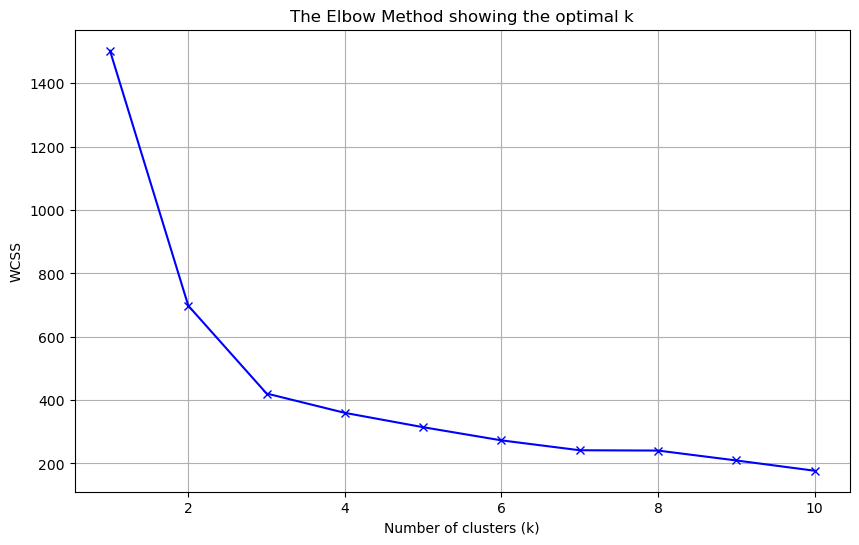

In [5]:
# --- TASK 4: K-MEANS ITERATION (ELBOW METHOD) ---

wcss = [] # Within-Cluster Sum of Squares
k_values = range(1, 11)

for k in k_values:
    # random_state ensures  results are reproducible
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

***Finidings of the Elbow Method***

    The objective of the Elbow Method is to find a balance between the number of clusters (k) and the Within-Cluster Sum of Squares (WCSS).
    
    The "Elbow": We are looking for the point where the rate of decrease shifts from sharp to marginal. We can see that the elbow clearly occurs at k=3.